In [2]:
import sys
print(sys.executable)

D:\FaceAnalysisProject\venv\Scripts\python.exe


In [3]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.12.1+cpu
0.27.1+cpu


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os


import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torch.cuda.amp import GradScaler
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
print(f"On device : {device}")

On device : cpu


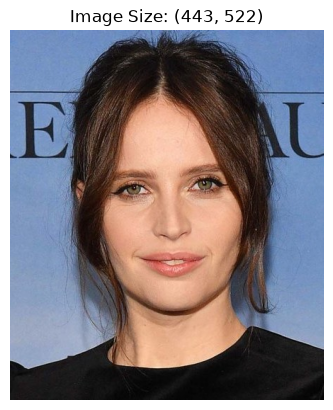

In [3]:
example_image_path = random.choice(os.listdir('D:\FaceAnalysisProject\dataset\Face Shape\FaceShape Dataset/training_set/Oval'))
example_image_path = os.path.join("D:\FaceAnalysisProject\dataset\Face Shape\FaceShape Dataset/training_set/Oval", example_image_path)
example_image = Image.open(example_image_path)

plt.imshow(example_image)
plt.title(f"Image Size: {example_image.size}")
plt.axis('off')
plt.show()

In [4]:
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [5]:
BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count() - 1
TRAIN_PATH = "D:\FaceAnalysisProject\dataset\Face Shape\FaceShape Dataset/training_set"
TEST_PATH = "D:\FaceAnalysisProject\dataset\Face Shape\FaceShape Dataset/testing_set"

def safe_pil_loader(path):
    try:
        with open(path, 'rb') as f:
            img = Image.open(f)
            return img.convert('RGB')
    except (OSError, SyntaxError):
        return Image.new('RGB', (224, 224))

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transforms, loader=safe_pil_loader)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=test_transforms, loader=safe_pil_loader)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [6]:
train_dataset.class_to_idx

{'Heart': 0, 'Oblong': 1, 'Oval': 2, 'Round': 3, 'Square': 4}

In [7]:
print(len(train_dataset))
print(len(test_dataset))
print(train_dataset.classes)

3998
1000
['Heart', 'Oblong', 'Oval', 'Round', 'Square']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].


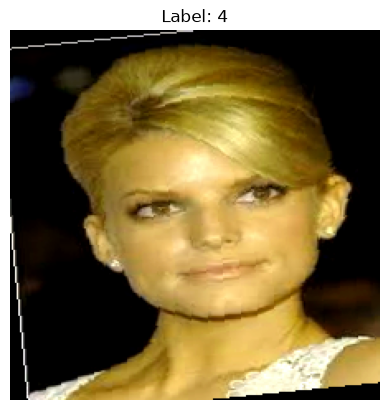

In [8]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

example_image = images[0]
example_image = example_image.permute(1, 2, 0).numpy()
example_label = labels[0].item()

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
example_image = example_image * std + mean

plt.imshow(example_image)
plt.title(f"Label: {example_label}")
plt.axis('off')
plt.show()

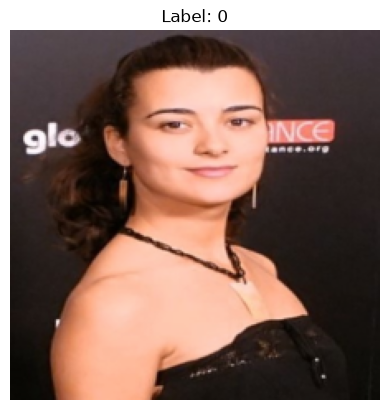

In [9]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

example_image = images[0]
example_image = example_image.permute(1, 2, 0).numpy()
example_label = labels[0].item()

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
example_image = example_image * std + mean

plt.imshow(example_image)
plt.title(f"Label: {example_label}")
plt.axis('off')
plt.show()

In [14]:
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau

torch.manual_seed(42)

model = models.efficientnet_b0(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = True

num_classes = len(train_dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.classifier[1].in_features, num_classes)
)

model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)

num_epochs = 25
best_val_loss = float("inf")

In [18]:
print("hello")

hello


In [17]:
### print("Training Started...")

best_val_loss = float("inf")

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================

    model.train()

    train_losses = []

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    # =========================
    # VALIDATION
    # =========================

    model.eval()

    validation_losses = []

    all_predictions = []

    all_labels = []

    with torch.inference_mode():

        for inputs, labels in test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            validation_losses.append(loss.item())

            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_val_loss = (
        sum(validation_losses)
        / len(validation_losses)
    )

    scheduler.step(avg_val_loss)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Accuracy: {accuracy:.4f}"
    )

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        os.makedirs(
            "models",
            exist_ok=True
        )

        torch.save(
            model.state_dict(),
            "models/best_model.pth"
        )

        print("Model Saved!")

print(
    f"Best Validation Loss: {best_val_loss:.4f}"
)

Epoch 1/25 | Train Loss: 0.1103 | Val Loss: 0.6336 | Accuracy: 0.8180
Model Saved!
Epoch 2/25 | Train Loss: 0.1032 | Val Loss: 0.6274 | Accuracy: 0.8110
Model Saved!
Epoch 3/25 | Train Loss: 0.0932 | Val Loss: 0.6285 | Accuracy: 0.8160


KeyboardInterrupt: 

In [18]:
model.load_state_dict(
    torch.load("models/best_model.pth", map_location=device)
)

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

<Figure size 800x600 with 0 Axes>

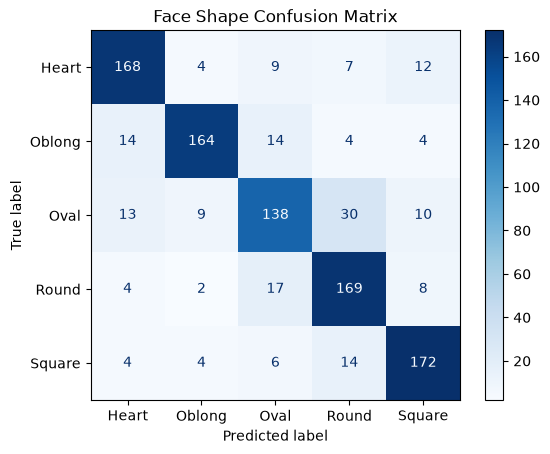

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.inference_mode():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Face Shape Confusion Matrix")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

       Heart       0.83      0.84      0.83       200
      Oblong       0.90      0.82      0.86       200
        Oval       0.75      0.69      0.72       200
       Round       0.75      0.84      0.80       200
      Square       0.83      0.86      0.85       200

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000

